In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import pickle 
import mlflow
import mlflow.sklearn
import warnings 
warnings.filterwarnings('ignore')

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
      RandomForestClassifier,
      GradientBoostingClassifier,  
      AdaBoostClassifier
)

In [39]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [40]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Features     :", feature_names)
print("Data loaded!")

X_train shape: (604, 21)
X_test shape : (152, 21)
Features     : ['id', 'age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'sex_Male', 'dataset_Hungary', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
Data loaded!


In [41]:
model={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "XGBoost"            : XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM"                : SVC(probability=True, random_state=42),
    "KNN"                : KNeighborsClassifier(n_neighbors=5),
    "AdaBoost"           : AdaBoostClassifier(n_estimators=100, random_state=42)
}

print(f"Total models: {len(model)}")

Total models: 7


In [42]:
mlflow.set_experiment("Heart_Attack_Prediction")

results = []
best_model = None
best_score = 0
best_model_name = ""

print("Training models...")
print("-" * 65)

for name, model in model.items():
    with mlflow.start_run(run_name=name):

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_prob)

        # Log to MLflow
        mlflow.log_metric("accuracy",  acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall",    rec)
        mlflow.log_metric("f1_score",  f1)
        mlflow.log_metric("roc_auc",   auc)
        mlflow.sklearn.log_model(model, name)

        # Store results
        results.append({
            "Model"    : name,
            "Accuracy" : round(acc,  4),
            "Precision": round(prec, 4),
            "Recall"   : round(rec,  4),
            "F1 Score" : round(f1,   4),
            "ROC AUC"  : round(auc,  4)
        })

        # Track best model using Recall
        if rec > best_score:
            best_score = rec
            best_model = model
            best_model_name = name

        print(f"{name}")
        print(f"   Accuracy:{acc:.4f} | Recall:{rec:.4f} | F1:{f1:.4f} | AUC:{auc:.4f}")
        print("-" * 65)

print(f"\n Best Model : {best_model_name}")
print(f" Best Recall: {best_score:.4f}")

Training models...
-----------------------------------------------------------------


2026/03/19 21:34:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 21:34:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression
   Accuracy:0.8421 | Recall:0.8816 | F1:0.8481 | AUC:0.8908
-----------------------------------------------------------------


2026/03/19 21:34:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 21:34:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/19 21:34:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest
   Accuracy:0.8487 | Recall:0.8421 | F1:0.8477 | AUC:0.9153
-----------------------------------------------------------------


...

Gradient Boosting
   Accuracy:0.8289 | Recall:0.8421 | F1:0.8312 | AUC:0.9084
-----------------------------------------------------------------


2026/03/19 21:34:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 21:34:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM
   Accuracy:0.7763 | Recall:0.7763 | F1:0.7763 | AUC:0.8579
-----------------------------------------------------------------
KNN
   Accuracy:0.7697 | Recall:0.7763 | F1:0.7712 | AUC:0.8199
-----------------------------------------------------------------


2026/03/19 21:34:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 21:34:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AdaBoost
   Accuracy:0.8224 | Recall:0.8158 | F1:0.8212 | AUC:0.9160
-----------------------------------------------------------------

 Best Model : Logistic Regression
 Best Recall: 0.8816


In [43]:
results_df = pd.DataFrame(results)

# Check column names
print("Columns:", results_df.columns.tolist())
print(results_df)
print(results_df.columns.tolist())
print(results_df.head())

Columns: ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8421     0.8171  0.8816    0.8481   0.8908
1        Random Forest    0.8487     0.8533  0.8421    0.8477   0.9153
2              XGBoost    0.8224     0.8101  0.8421    0.8258   0.9074
3    Gradient Boosting    0.8289     0.8205  0.8421    0.8312   0.9084
4                  SVM    0.7763     0.7763  0.7763    0.7763   0.8579
5                  KNN    0.7697     0.7662  0.7763    0.7712   0.8199
6             AdaBoost    0.8224     0.8267  0.8158    0.8212   0.9160
['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8421     0.8171  0.8816    0.8481   0.8908
1        Random Forest    0.8487     0.8533  0.8421    0.8477   0.9153
2              XGBoost    0.8224     0.8101  0.8421    0.8258   0.9074
3  

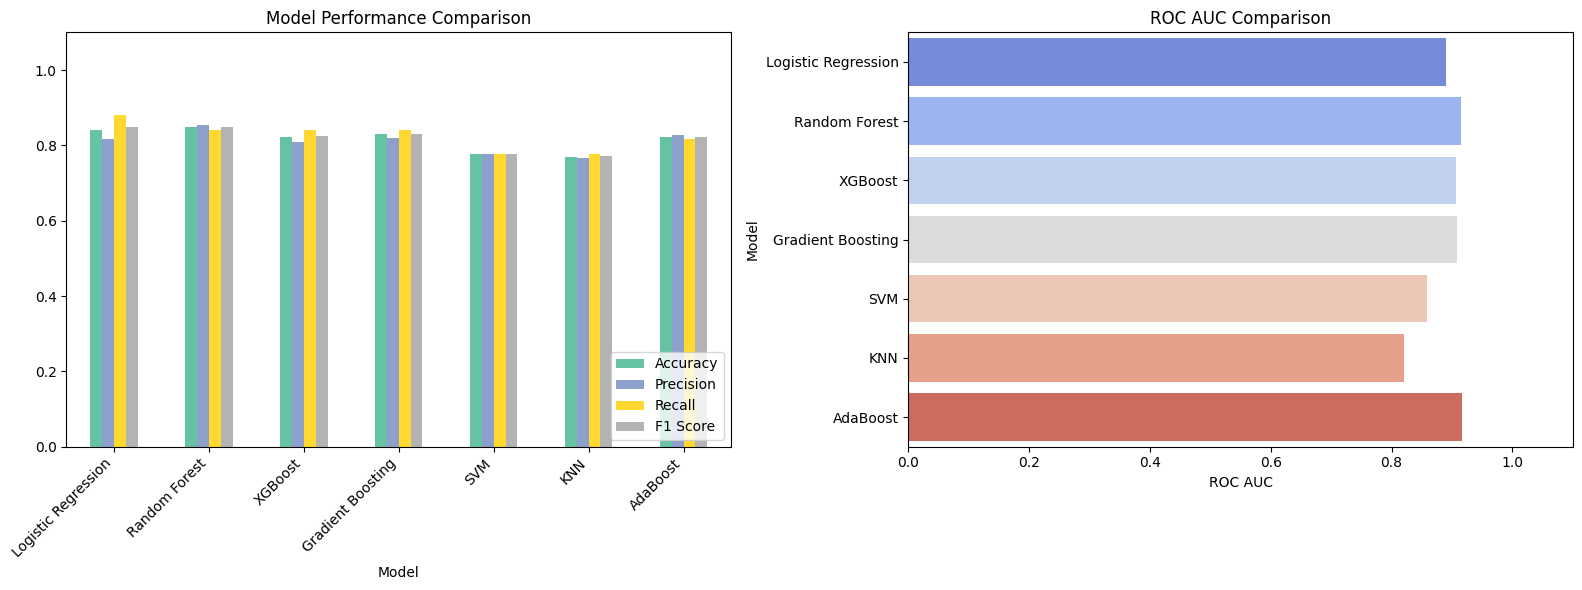

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
results_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar', ax=axes[0], colormap='Set2'
)  
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')

# ROC AUC comparison
sns.barplot(
    x='ROC AUC', y='Model',
    data=results_df, palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('ROC AUC Comparison')
axes[1].set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

In [1]:
import os
import pickle

# Create models folder
models_dir = os.path.join(
    os.path.expanduser("~"),
    "Desktop", "Heart-Attack-Prediction", "models"
)
os.makedirs(models_dir, exist_ok=True)

# Save best model
with open(os.path.join(models_dir, 'best_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open(os.path.join(models_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open(os.path.join(models_dir, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)

print("✅ All files saved!")
print(f"📁 Saved to: {models_dir}")

NameError: name 'best_model' is not defined